# On Computing, Data Centers, and the Environment

## **Jed Brown**, CU Boulder


## 2025-08-06

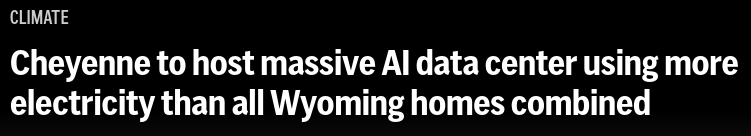

> The latest data center, a joint effort between regional energy infrastructure company Tallgrass and AI data center developer Crusoe, would begin at 1.8 gigawatts of electricity and be scalable to 10 gigawatts, according to a joint company statement.
>
> A gigawatt can power as many as 1 million homes. But that’s more homes than Wyoming has people. The least populated state, Wyoming, has about 590,000 people.

> “This is exciting news for Wyoming and for Wyoming **natural gas producers**,” [Gov.] Gordon said in the statement.

* 1 GW of "AI" data center = \$50 B in hardware (GPUs, etc.) that gets replaced each 5-ish years.
* That puts this project at about $40000/year per WY resident in amortized capex.

> Wyoming. Tax abatements are provided for sales, use, and property taxes based on investment, with additional breaks for multi-tenant data centers. -- [Sustainable Digital Infrastructure Alliance](https://knowledge.sdialliance.org/8d367baa340046029912b1e04cc89ec2)

https://apnews.com/article/ai-artificial-intelligence-data-center-electricity-wyoming-cheyenne-44da7974e2d942acd8bf003ebe2e855a

# Putting scientific computing in context

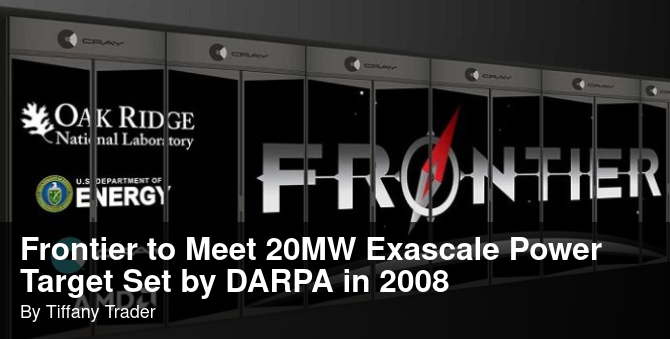

> “You might wonder, where did that [20 MW number] come from?” Geist posed. **“Actually, it came from a totally non-technical evaluation of what was possible. What was possible said: it’s gonna take 150 MW. What we said is: we need it to be 20 [MW]. And why we said that is that [we asked] the DOE, ‘How much are they willing to pay for power over the life of a system?’** and the number that came back from the head of Office of Science at the time was that they weren’t willing to pay over \\$100 million over the five years, so it’s simple math [based on an average cost of \$1 million per megawatt per year]. The 20 megawatts had nothing to do with what might be possible, it was just that stake that we drove in the ground.”

https://www.hpcwire.com/2021/07/14/frontier-to-meet-20mw-exascale-power-target-set-by-darpa-in-2008/

## Aurora uses 39 MW

## The 20 MW target was a PR campaign

* People take pride in working within environmental impact constraints vs simple budget constraints.

* 300 MW commercial data centers existed or were in development when the target was set.

* Energy cost is dwarfed by acquisition cost.

# About that 1.8 GW data center in WY

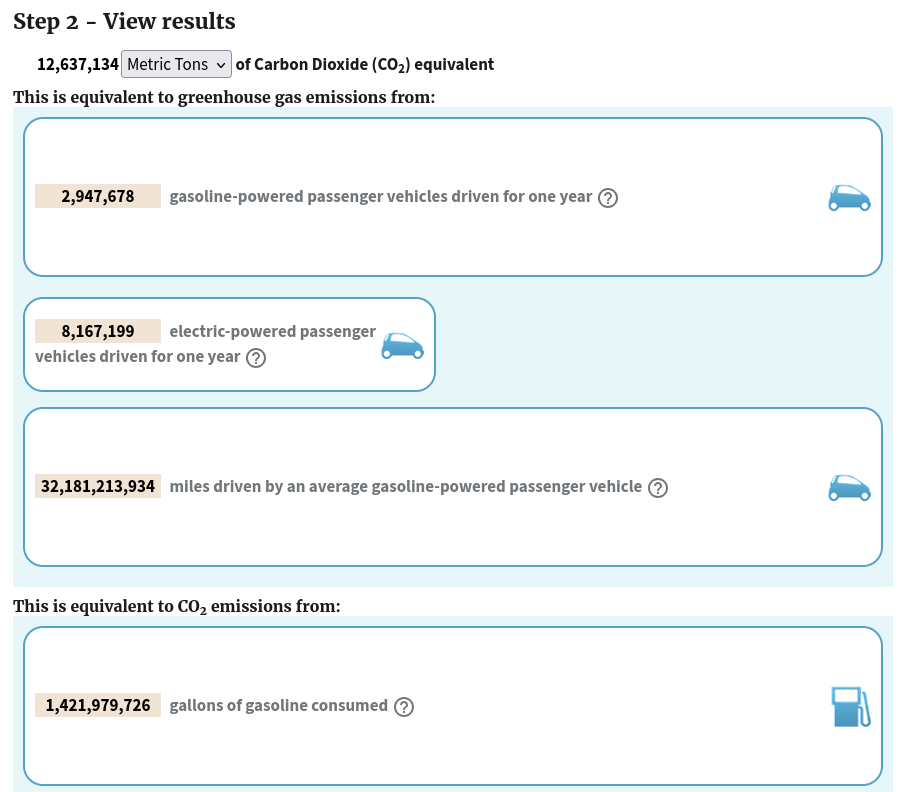

# Emission scopes

<img src="figures/env/EmissionScopes.png" width="80%" />

https://www.carbonneutral.com/news/scope-1-2-3-emissions-explained

# Scope 2 vs Scope 3 for data centers

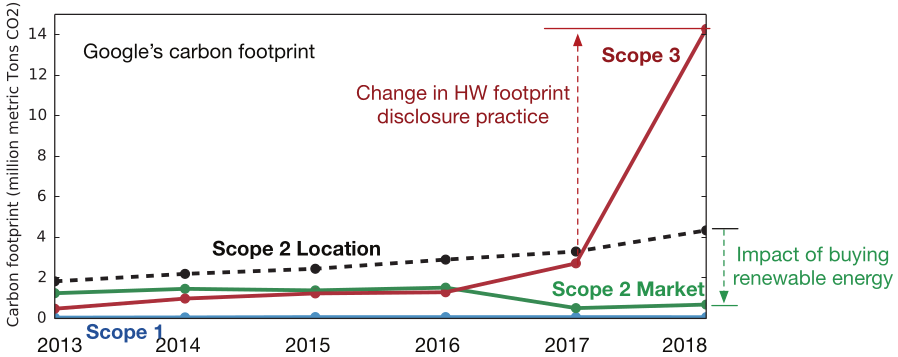

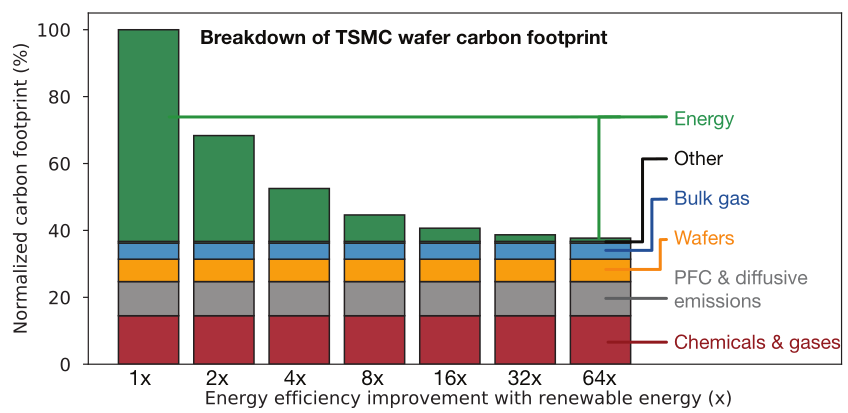

Gupta et al (2021) https://doi.org/10.1109/HPCA51647.2021.00076

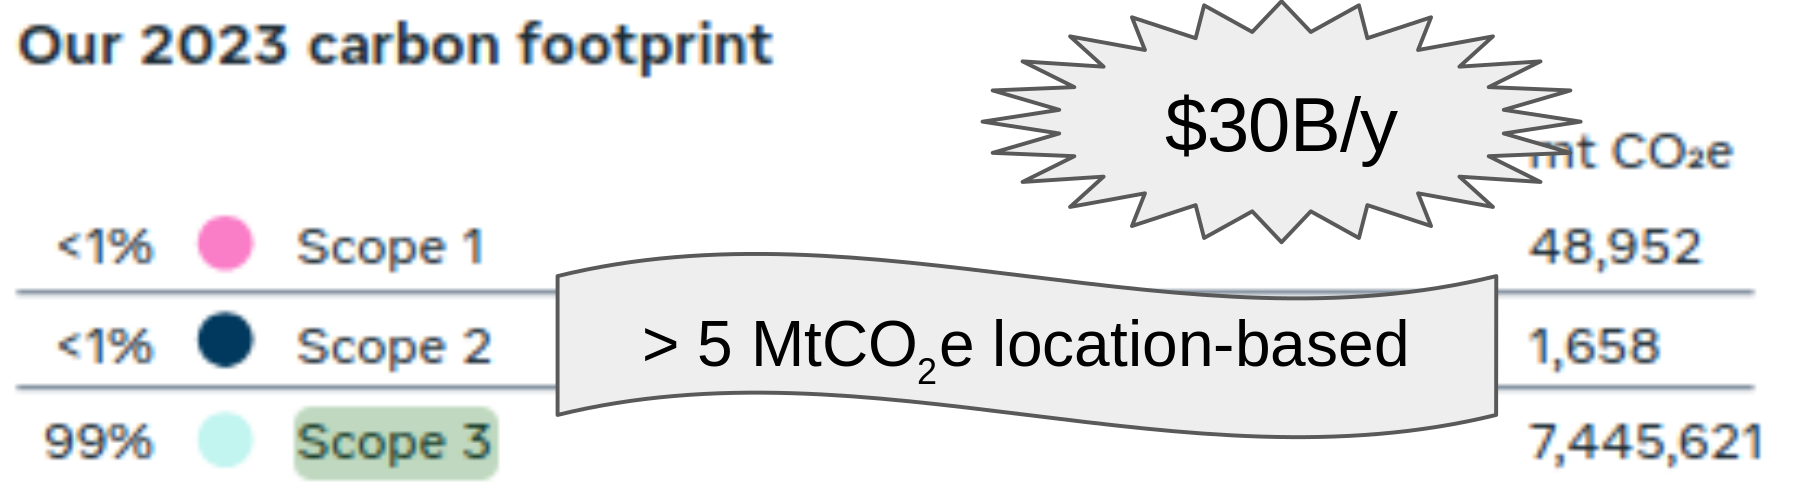
https://sustainability.atmeta.com/wp-content/uploads/2024/08/Meta-2024-Sustainability-Report.pdf

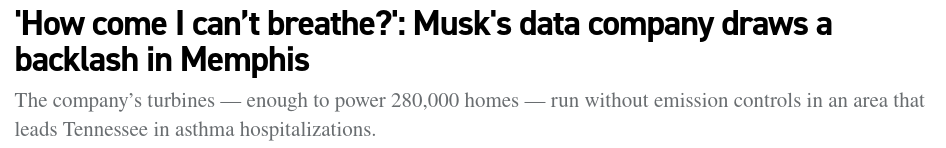
https://www.politico.com/news/2025/05/06/elon-musk-xai-memphis-gas-turbines-air-pollution-permits-00317582?mc_cid=e5925fcb2d&mc_eid=bc420c7b68

# Scope 2 location-based vs market-based

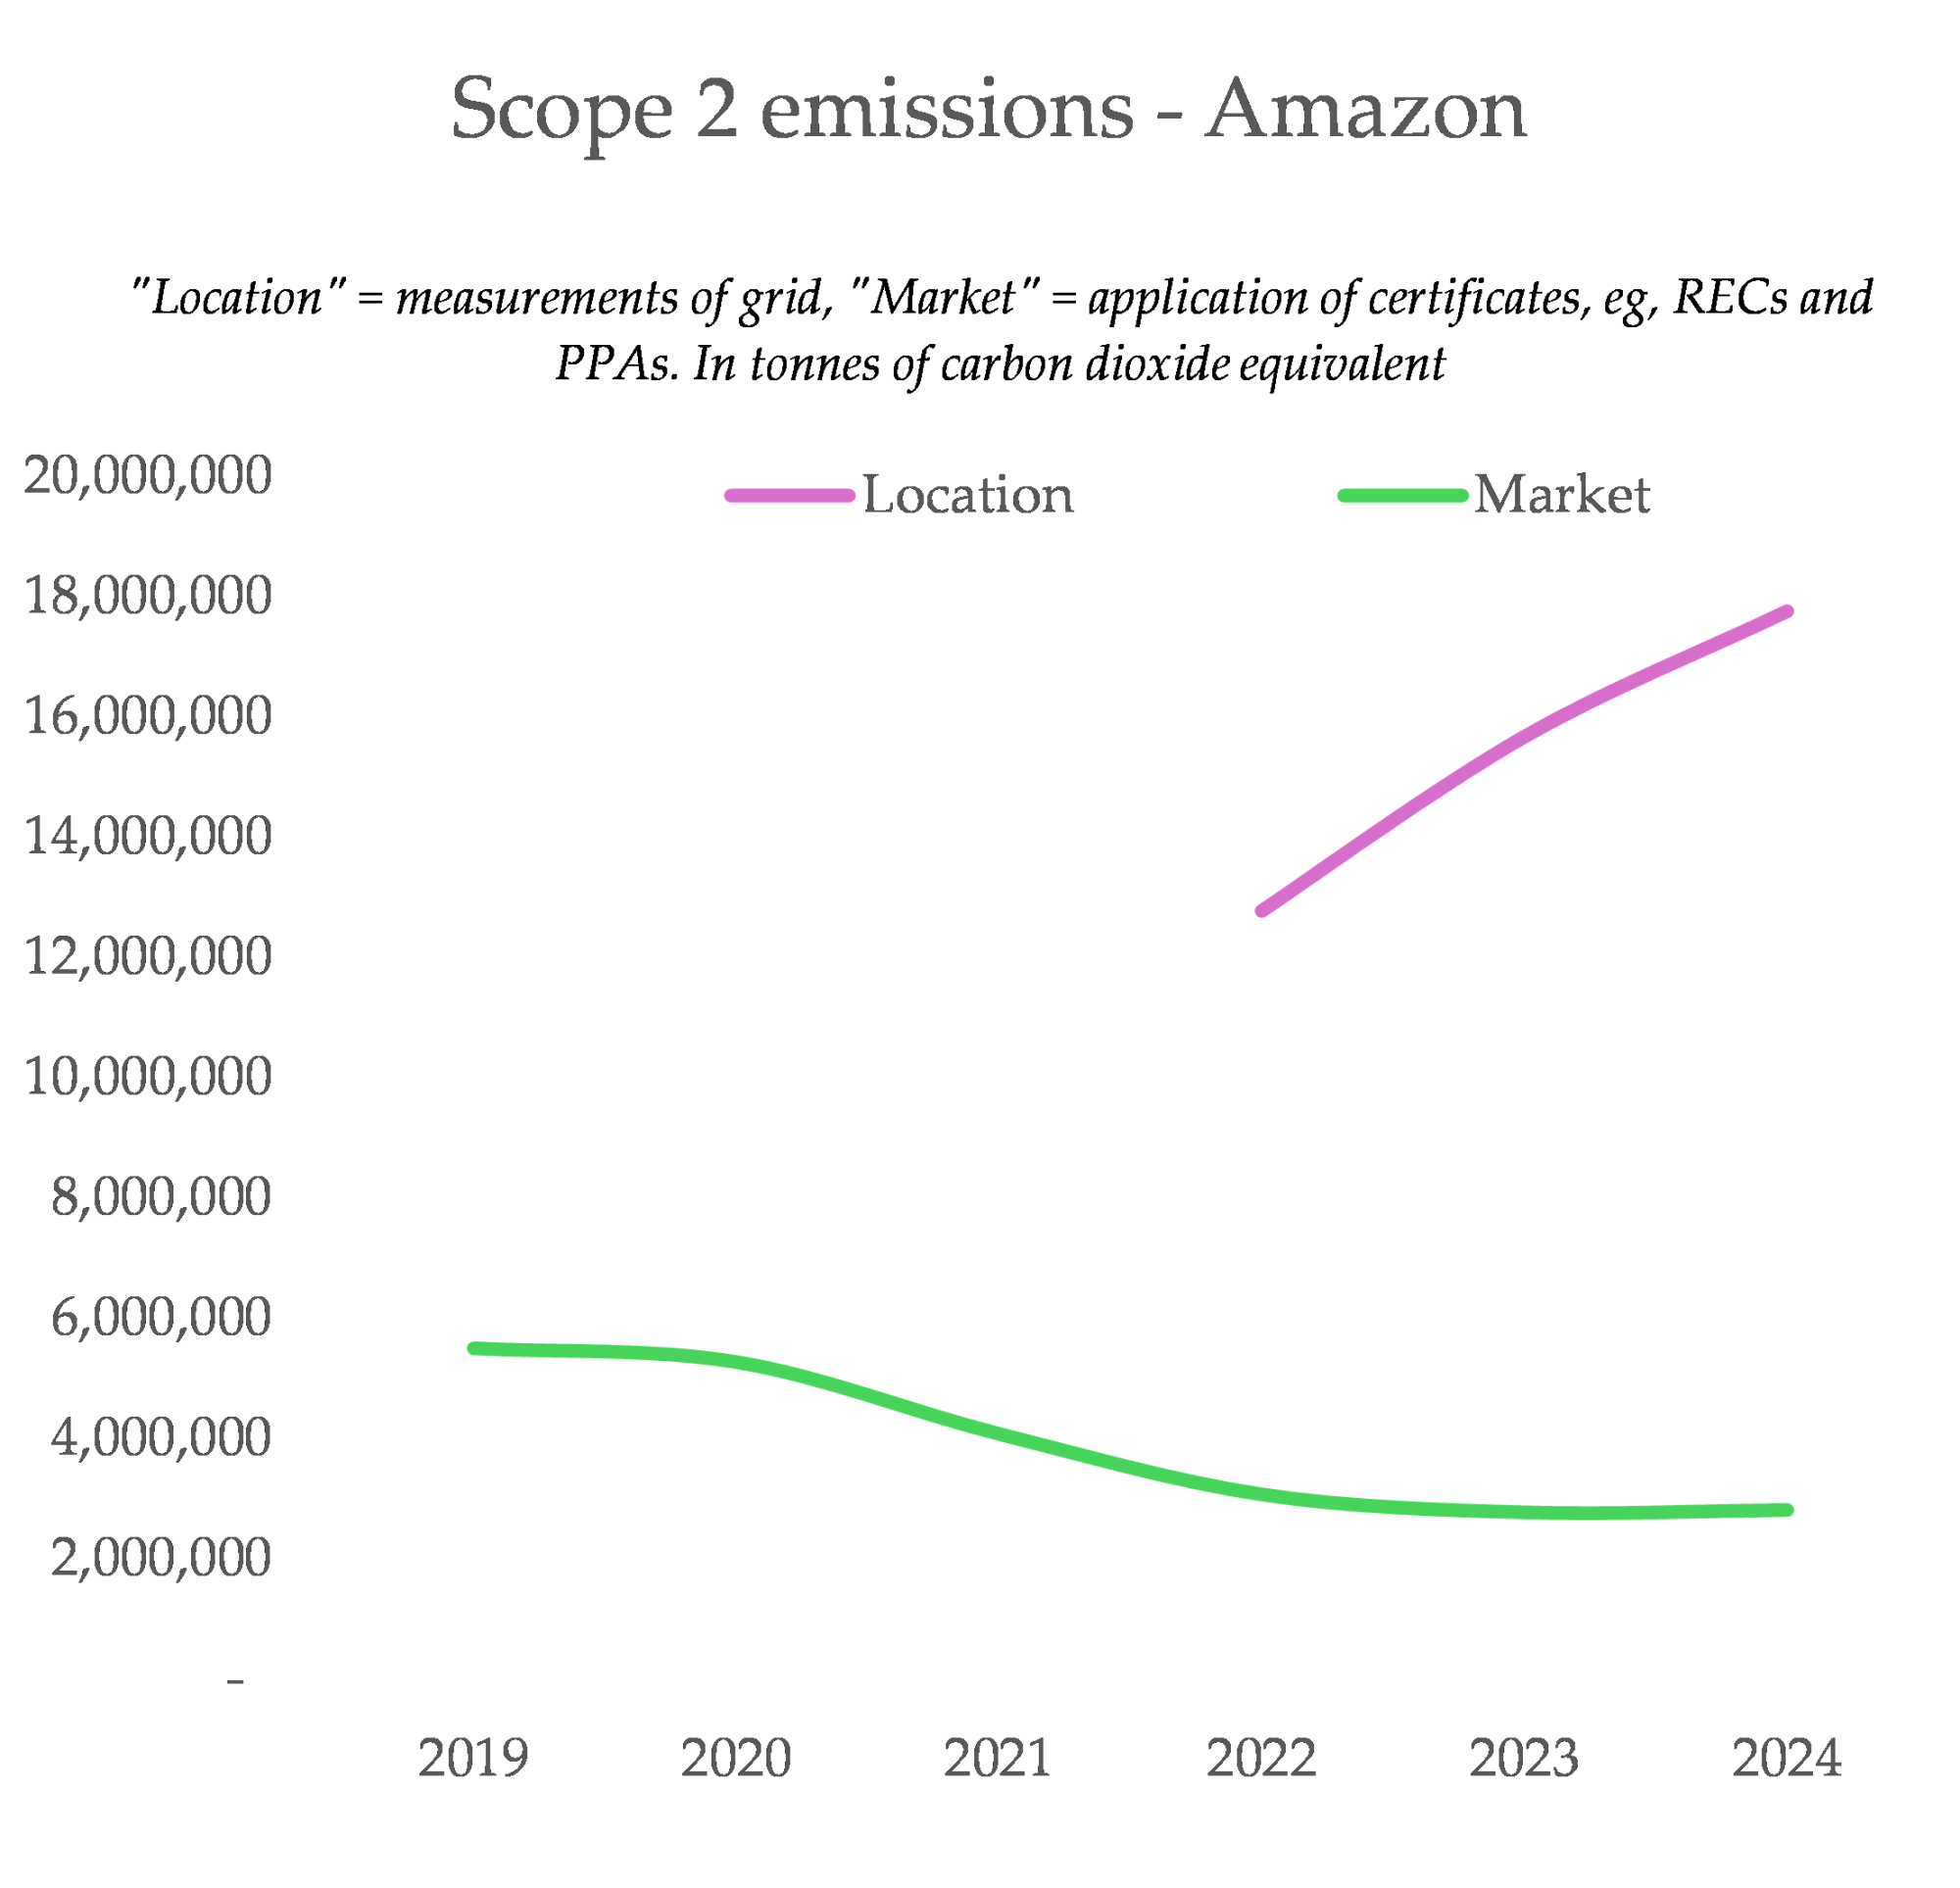

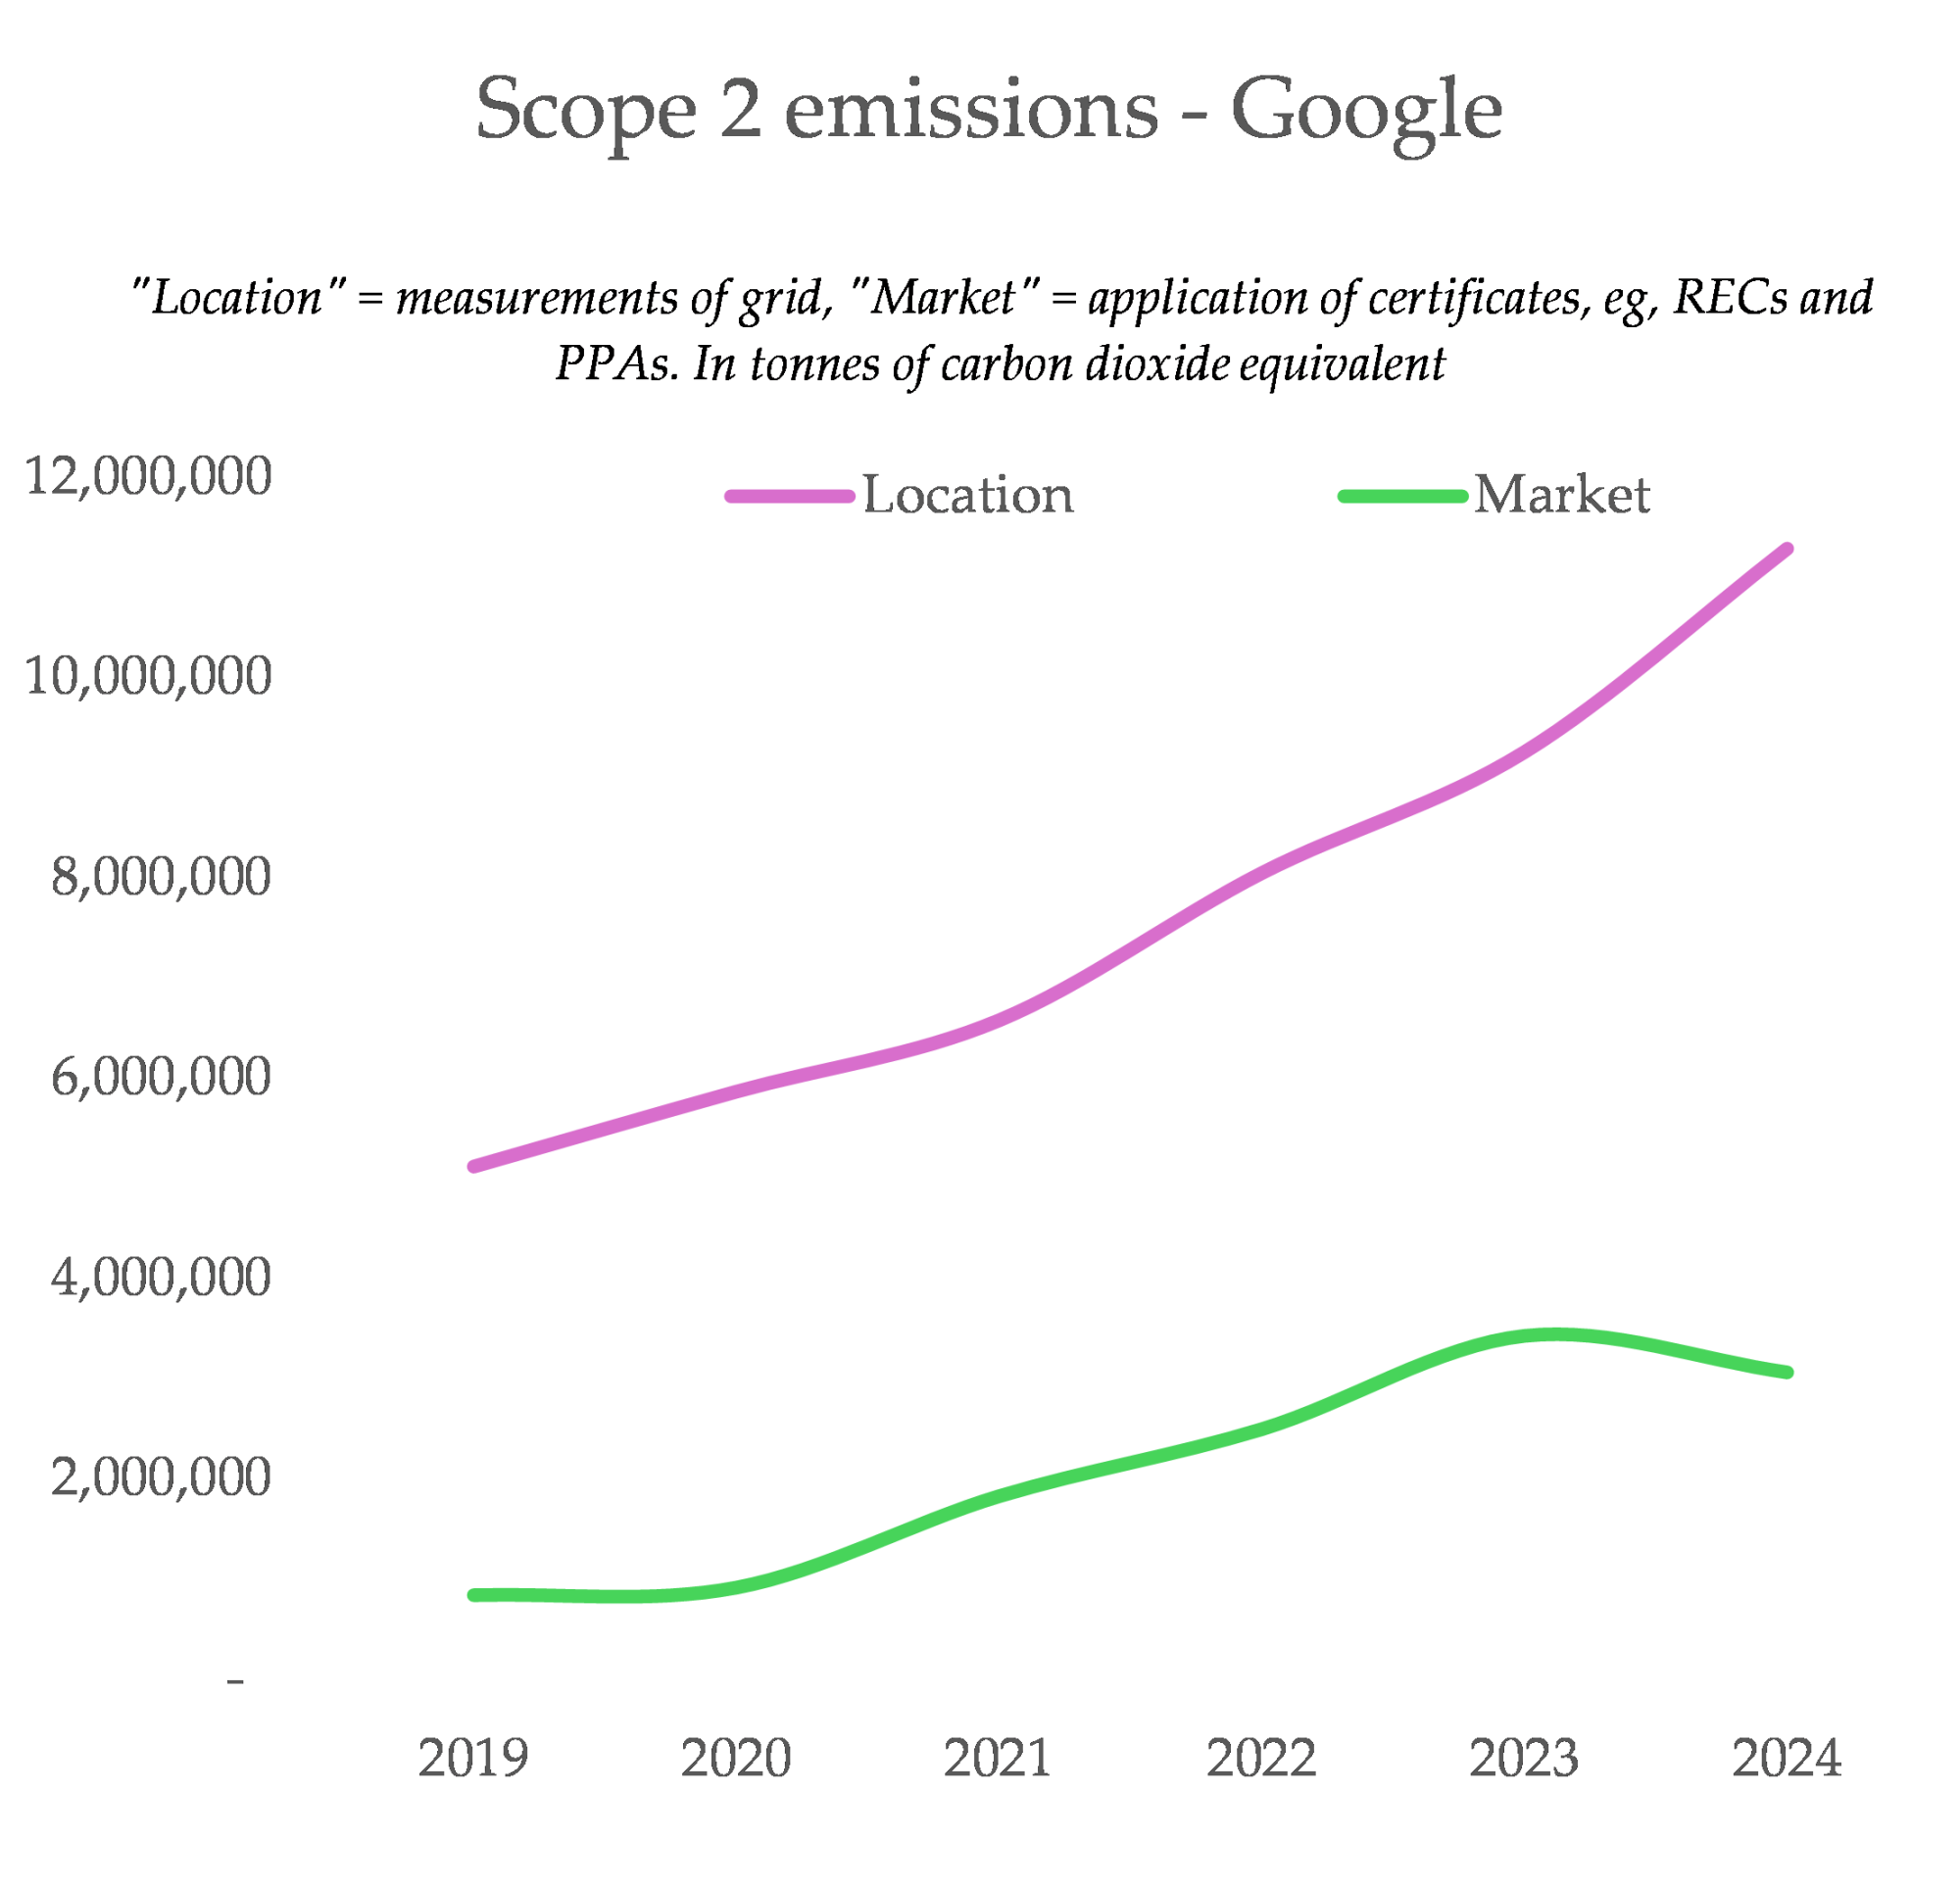

https://ketanjoshi.co/2025/05/23/data-collection-big-tech-emissions-energy/

# Market-based is dubious at best

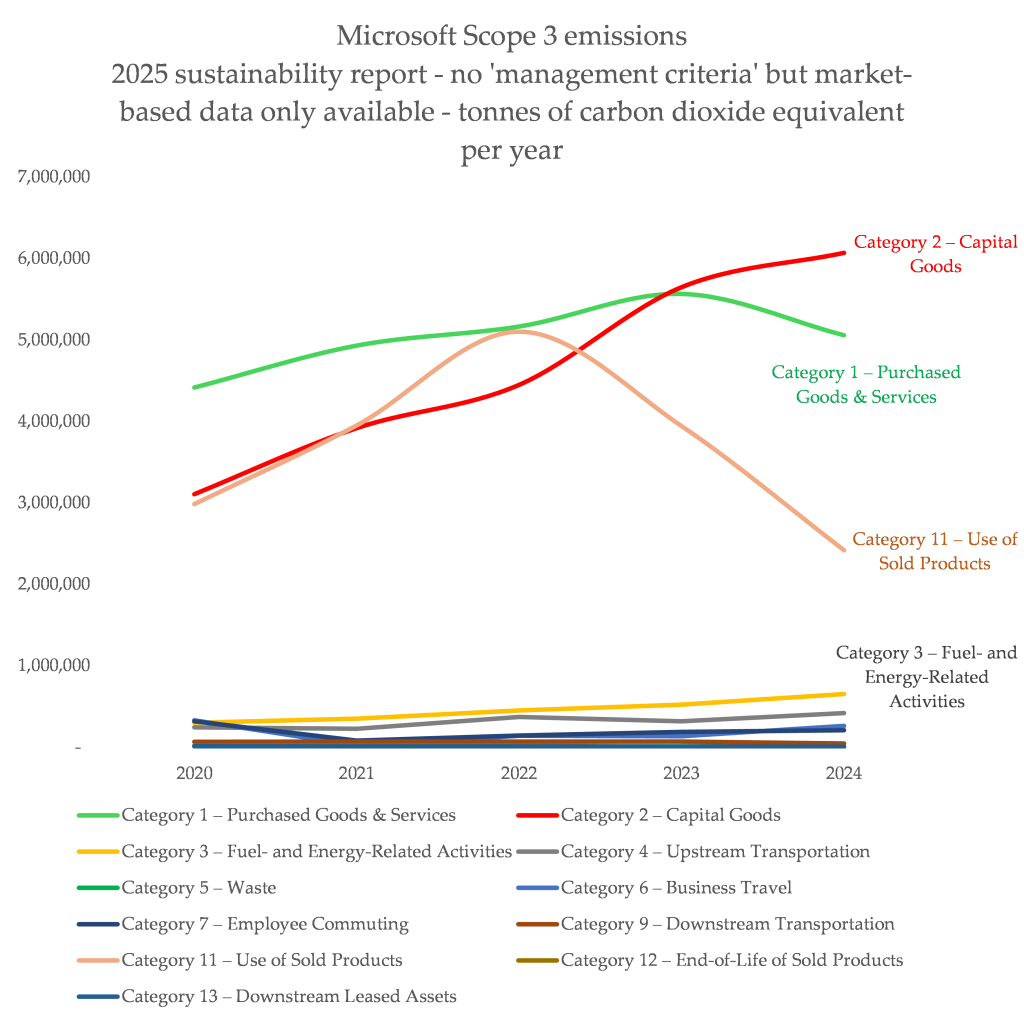

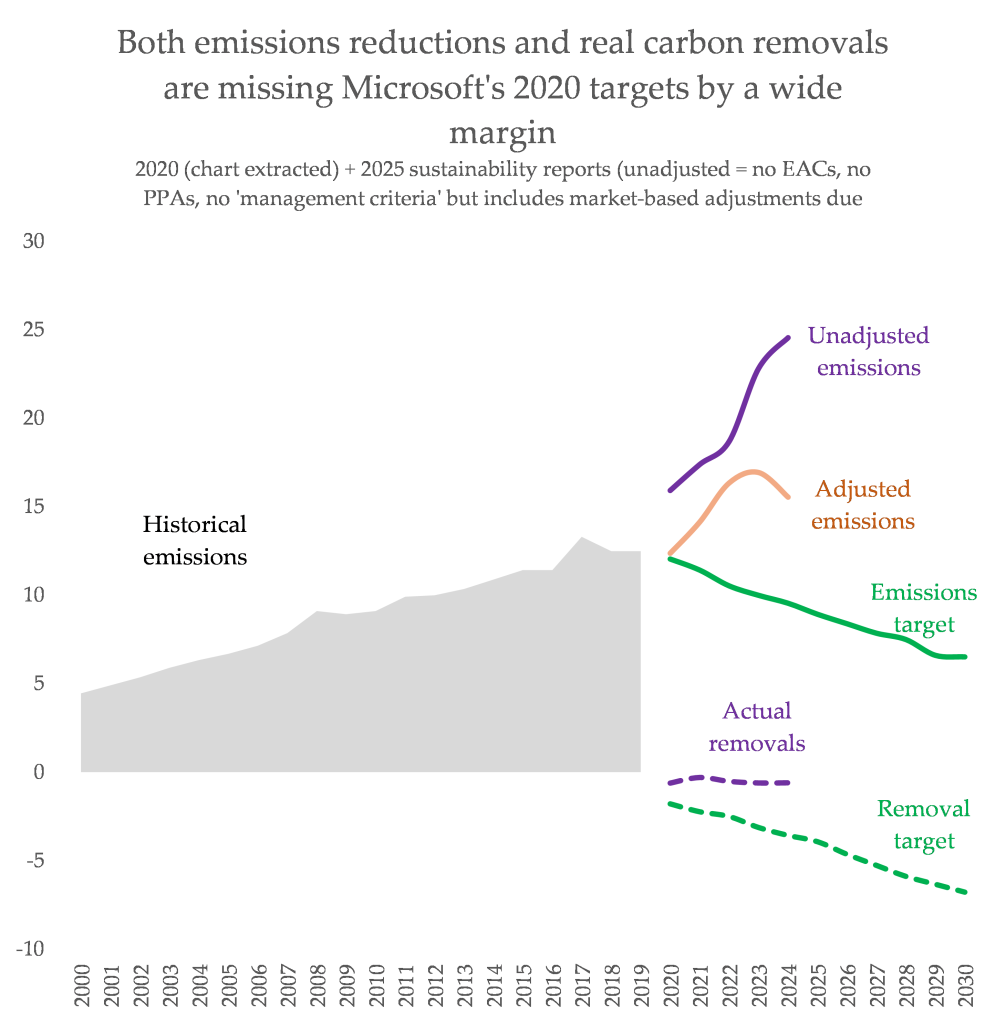

https://ketanjoshi.co/2025/05/31/the-life-and-death-of-microsofts-moonshot/

# Jevons effect/"paradox"

## DeepSeek (Jan 27, 2025)

* DeepSeek competitive LLM that was trained at a fraction the cost of leading US firms
* **Gasp!** build-out exceeding demand?
* [NVIDIA loses \$589 B in one day](https://www.nbcnews.com/business/markets/tech-stocks-react-chinas-deepseek-sparks-us-worries-ai-race-rcna189394)
* Investor vibes shift: lower costs will be more than offset by increased demand
* Market rebounds

<img src="figures/env/SVGZ_PEPI-data-centers_Exh1.svg" width="80%" />

## "Agentic"

**Tired:** issuing one prompt at a time

**Wired:** editor automatically issues prompts while you're working, applies changes to project

**Inspired:** issue prompts in a loop checking for code that compiles/passes tests; automatically issue shell commands and apply changes system-wide

## Science analogy
* Forward simulation -> inverse problems, Bayesian UQ, optimization

# How big?

* Data center CAPEX in 2025 added more to GDP than all consumer spending.

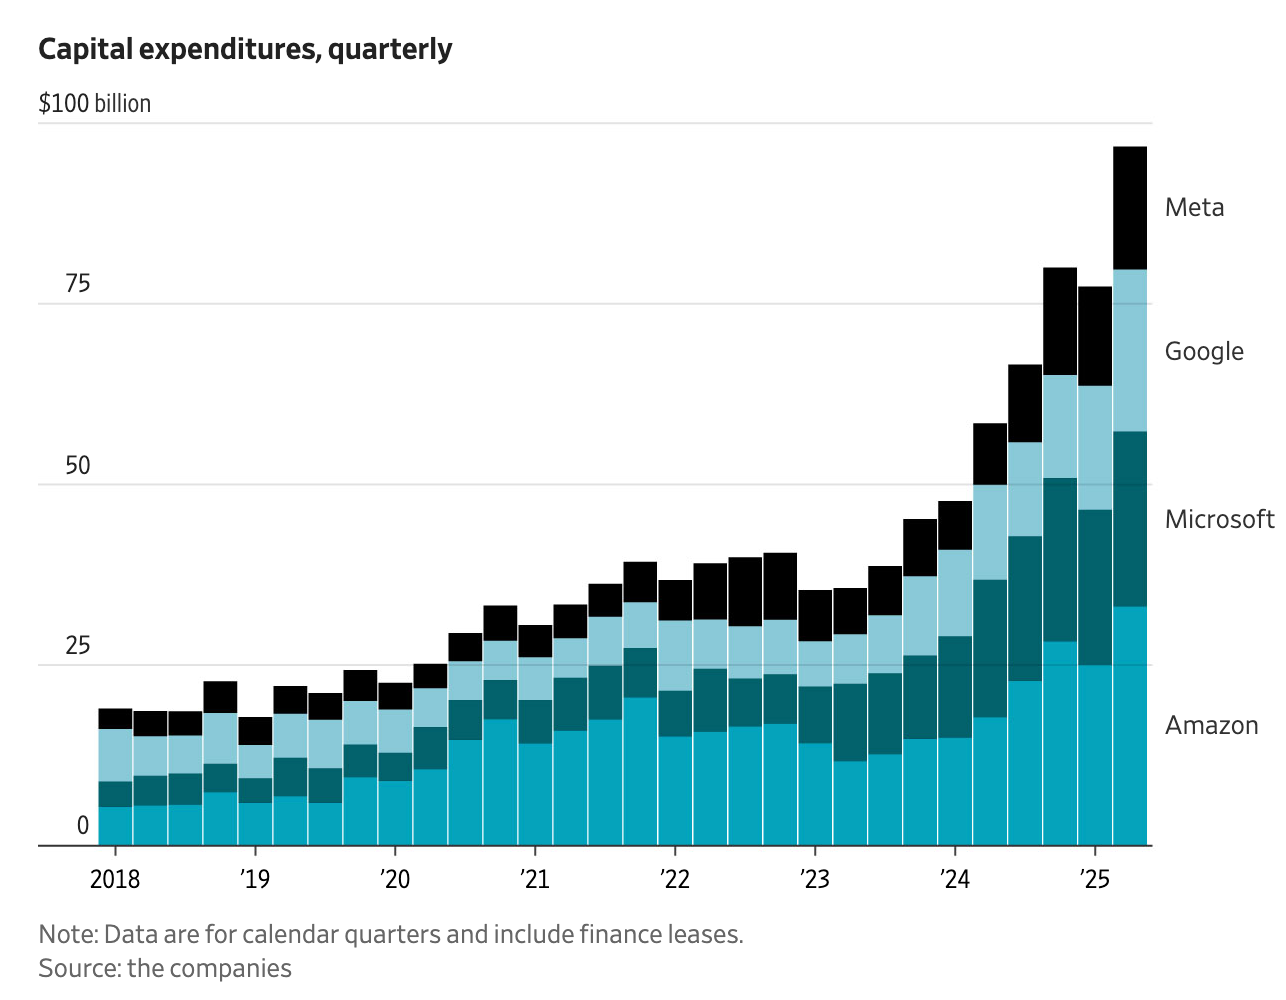

Source: [WSJ](https://www.wsj.com/tech/ai/silicon-valley-ai-infrastructure-capex-cffe0431)

> Spending on constructing datacenters and manufacturing facilities for computers & electronic products in the US now exceeds the entire retail and wholesale industry and almost as much as the rest of the office and manufacturing sectors combined.


<img src="figures/hardware/DataCenterConstruction.png" width="90%" />

https://bsky.app/profile/domw.bsky.social/post/3lvnrzn4vtk2t


# What is responsible computing?

* Insist on epistemic soundness
* Ask well-posed questions
* Verification and Validation before production runs
* Choose Pareto-optimal methods
* Choose data structures that minimize memory motion
* Vectorization and tuning

In [12]:
using Plots
default(linewidth=3)
using LinearAlgebra

function vander(x, k=nothing)
    if k === nothing
        k = length(x)
    end
    V = ones(length(x), k)
    for j = 2:k
        V[:, j] = V[:, j-1] .* x
    end
    V
end

function fdstencil(source, target, k)
    "kth derivative stencil from source to target"
    x = source .- target
    V = vander(x)
    rhs = zero(x)'
    rhs[k+1] = factorial(k)
    rhs / V
end

function poisson_fd(x, spoints, forcing; left=(0, zero), right=(0, zero))
    n = length(x)
    L = zeros(n, n)
    rhs = forcing.(x)
    for i in 2:n-1
        jleft = min(max(1, i-spoints÷2), n-spoints+1)
        js = jleft : jleft + spoints - 1
        L[i, js] = -fdstencil(x[js], x[i], 2)
    end
    L[1,1:spoints] = fdstencil(x[1:spoints], x[1], left[1])
    L[n,n-spoints+1:n] = fdstencil(x[n-spoints+1:n], x[n], right[1])
    rhs[1] = left[2](x[1])
    rhs[n] = right[2](x[n])
    L, rhs
end

poisson_fd (generic function with 1 method)

# Insist on epistemic soundness

> What most experimenters take for granted before they begin their experiments is infinitely more interesting than any results to which their experiments lead. -- Norbert Wiener

* Scrutinize the premise of the problem
* How do we know what we take for granted?
* Distinguish "right" from "right for the right reasons"
* Does the solution advance knowledge?

# [PDEBench (2022)](https://github.com/pdebench/PDEBench/)

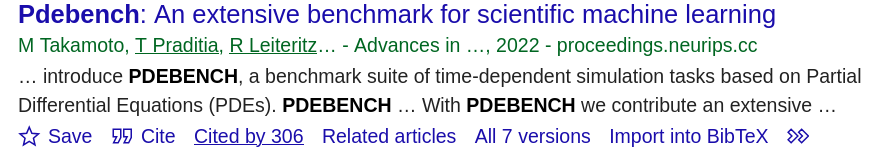

* The parameters in the paper claims to model 3D turbulence at **Reynolds number $10^8$ using a $64\times 64\times 64$ grid and a second-order spatial discretization**.

* Simulation cost scales as $\textrm{Re}^3$.
* $\textrm{Re} \approx 10^8$ is about a billion times more expensive than the largest simulations that have been today.
* The $64^3$ resolution has been feasible for nearly 50 years

## Conclusion

The benchmark result intended for use is nonsense.

# Ask well-posed questions

* There is no point dwelling on point estimates for chaotic systems
* Plan for statistical convergence rates and ergodic scales ahead of time
* Ensure appropriate boundary conditions
* ...

# Verification and Validation before production runs

# 38 years ago: [Journal of Fluids Engineering](https://jedbrown.org/files/RoacheGhiaWhite-JFEEditorialPolicyStatementControlOfNumericalAccuracy-1986.pdf)

<img src="figures/JFENumericalAccuracy.png" width="90%" />

* “it was impossible to compare the
accuracy of different turbulence
models, since one could not
distinguish physical modeling errors
from numerical errors related to the
algorithm and grid.”

<img src="figures/JFENumericalAccuracy2.png" width="90%" />

# Verification

## solving the problem right

# Validation

## solving the right problem

Verification is a mathematical activity that can, in principle, be completed (though one must always establish sufficient resolution). Validation is always ongoing, subject to tolerances and regime.


# Why is reliability so important?

Modeling and simulation is used to plan at the greatest scale.

* Dams, bridges
* Toxic/nuclear waste management
* Nuclear stockpile stewardship
* Climate policy/water resource management/reinsurance
* Airplanes, etc.

**We can't just 3d print a bunch of widgets and load test them. Tests are expensive (billions over many years) or worse.**

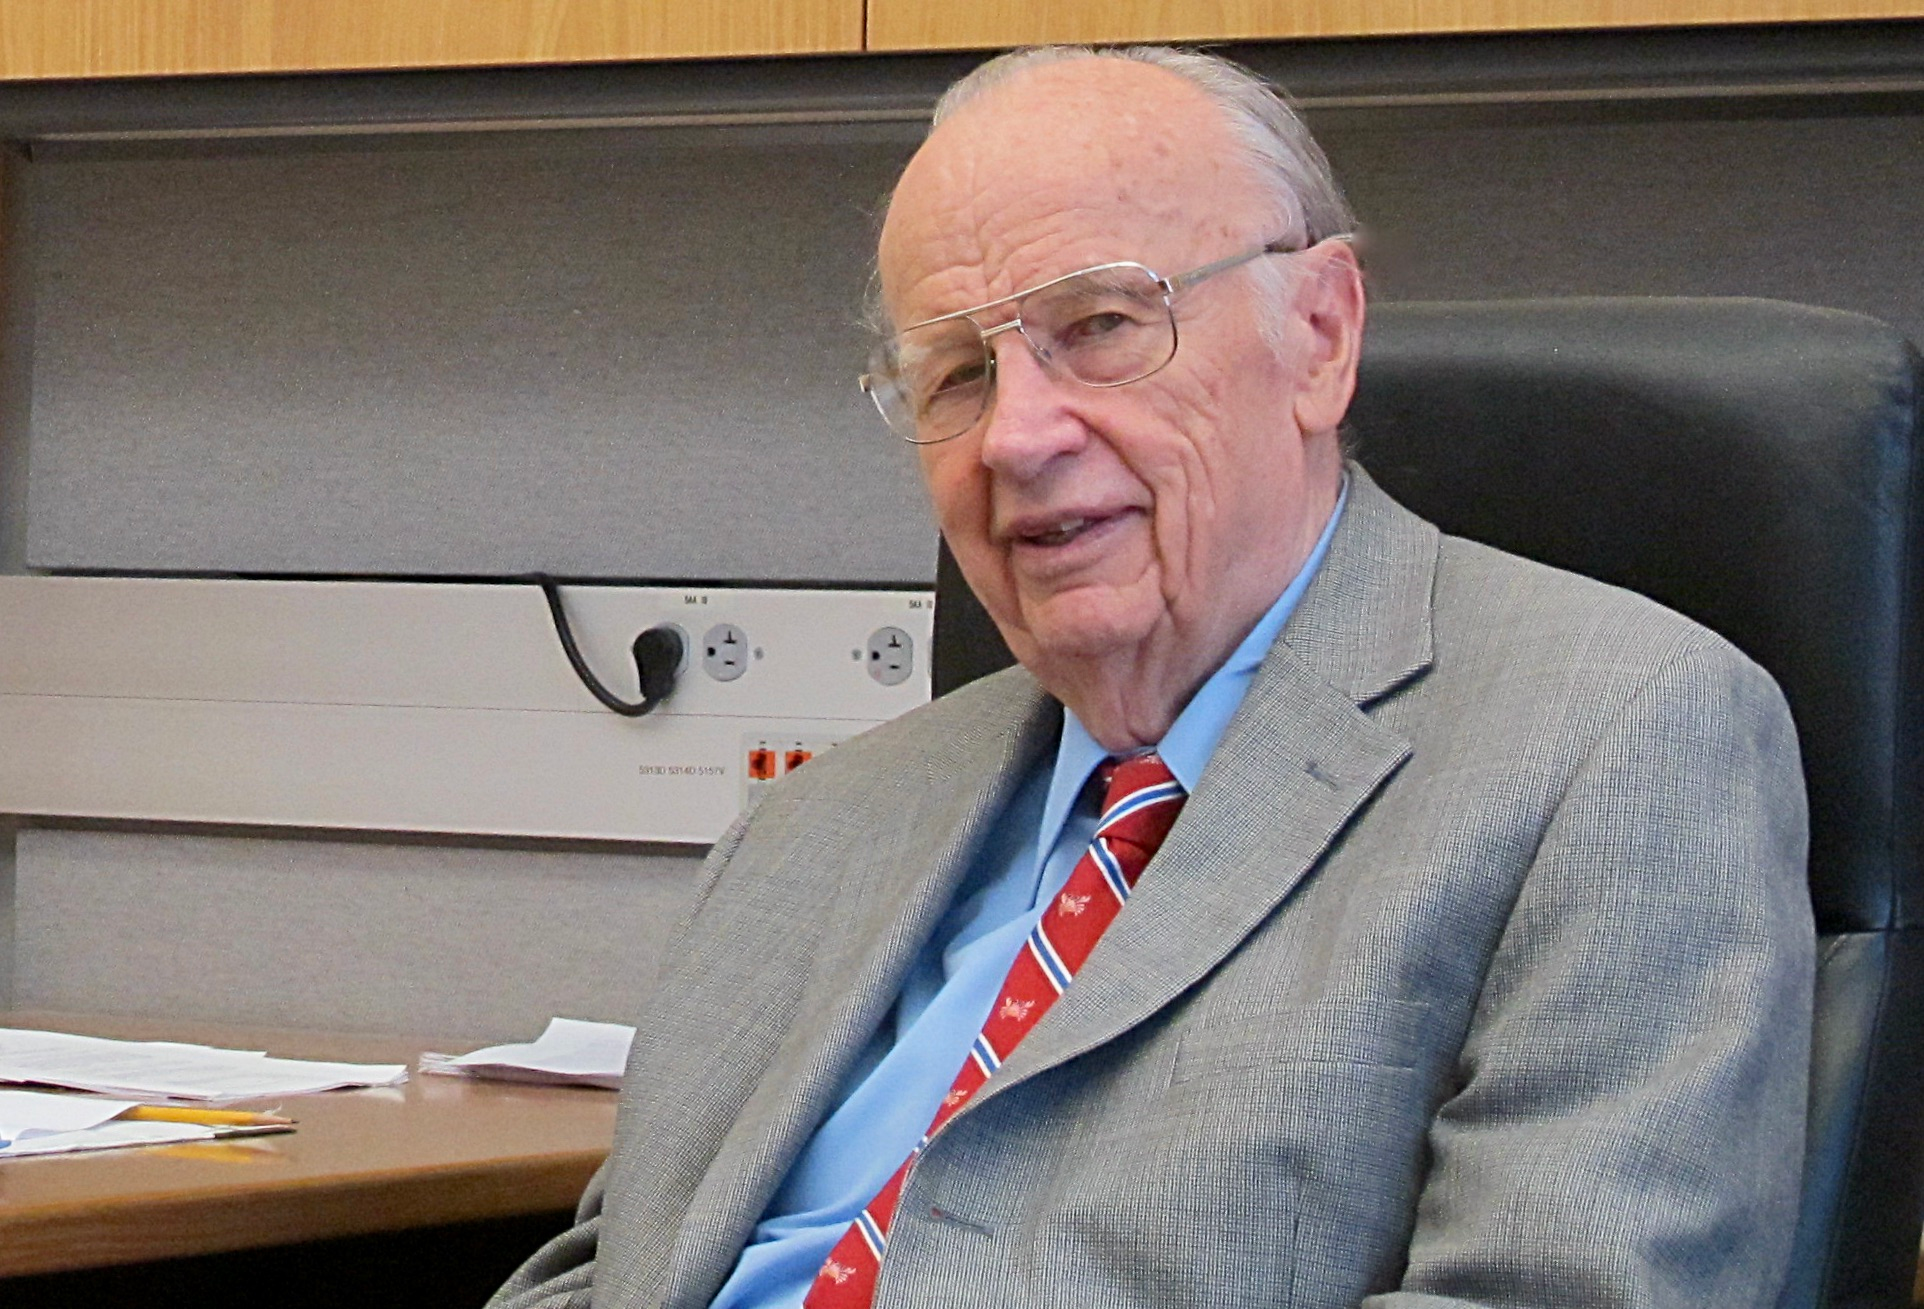

## "Will you sign the blueprint?"

-- Ivo Babuška

# Choose Pareto-optimal methods

<img src="figures/ratel/accuracy_study_annotated.svg" width="85%" />

# Choose data structures that minimize memory motion

<img src="figures/hardware/Shalf2020Fig5.png" width="80%" />

Shalf (2020) https://doi.org/10.1098/rsta.2019.0061

<img src="figures/ratel/schwarz-apply-2025.svg" />

# Do less

<img src="figures/fluids/libceed-apply-polaris-james.png" />

<img src="figures/ratel/SI-schwarz-q2-SI-matrixTypes-TotalSolveTime-Tioga.svg" />

<img src="figures/ratel/ratel-white.svg" />

# Vectorization and tuning

* Choose a machine that is good for your problem, problem size, and software.
* Choose high-quality libraries
* Optimize what matters

# Deliberately not listed: energy-efficient algorithms

Running slower at lower power: amortized scope 3 offsets marginal gains

# Definition of ML (or AI)

# [NAIRR definition (2023)](https://www.ai.gov/wp-content/uploads/2023/01/NAIRR-TF-Final-Report-2023.pdf)

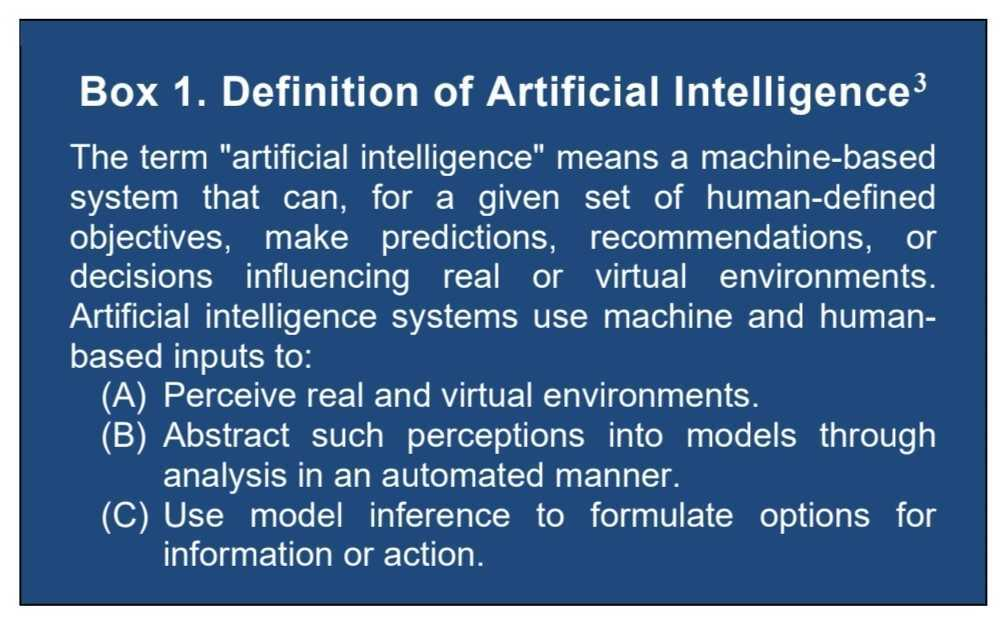

![](figures/tap-the-sign-nwp-ai.png)

# Narayanan and Kappor (2024) "AI Snake Oil"

> 1. Does the task require creative effort or training for a human to perform? [page 12]
> 2. Was the behavior of the system directly specified in code by the developer, or did it indirectly emerge, say by learning from examples or searching through a database? [page 13]
> 3. … whether the system makes decisions more or less autonomously and possesses some degree of flexibility and adaptability to the environment. [page 13]


![](figures/tap-the-sign-nwp-ai.png)

# Is it even techical?

> AI (or ML) is not a well-defined technology, but a cultural affinity signal of disregard for harms resulting from shoddy systems.

-- me (past several years)

> I think we should shed the idea that AI is a technological artifact with political features and recognize it as a political artifact through and through. **AI is an ideological project to shift authority and autonomy away from individuals, towards centralized structures of power.**

-- [Ali Alkhatib: Defining AI (2024)](https://ali-alkhatib.com/blog/defining-ai)

# De-facto technical definition

## Machine Learning is whatever is not-too-awkward to implement in PyTorch today.

## Excludes

* Adaptive algorithms (in number of steps, "layer" shape, etc.)
* Many "implicit layers", unless the right person implemented/published them.

## Social harms

* "we'll know it when we see it" gives license to ignore prior work and expertise
* it diverts funding from well-founded abstractions and systems
* allows selling all manner of "magical thinking"
* captures control

# McGreivy and Hakkim (2024)
## Weak baselines and reporting biases lead to overoptimism in machine learning for fluid-related partial differential equations

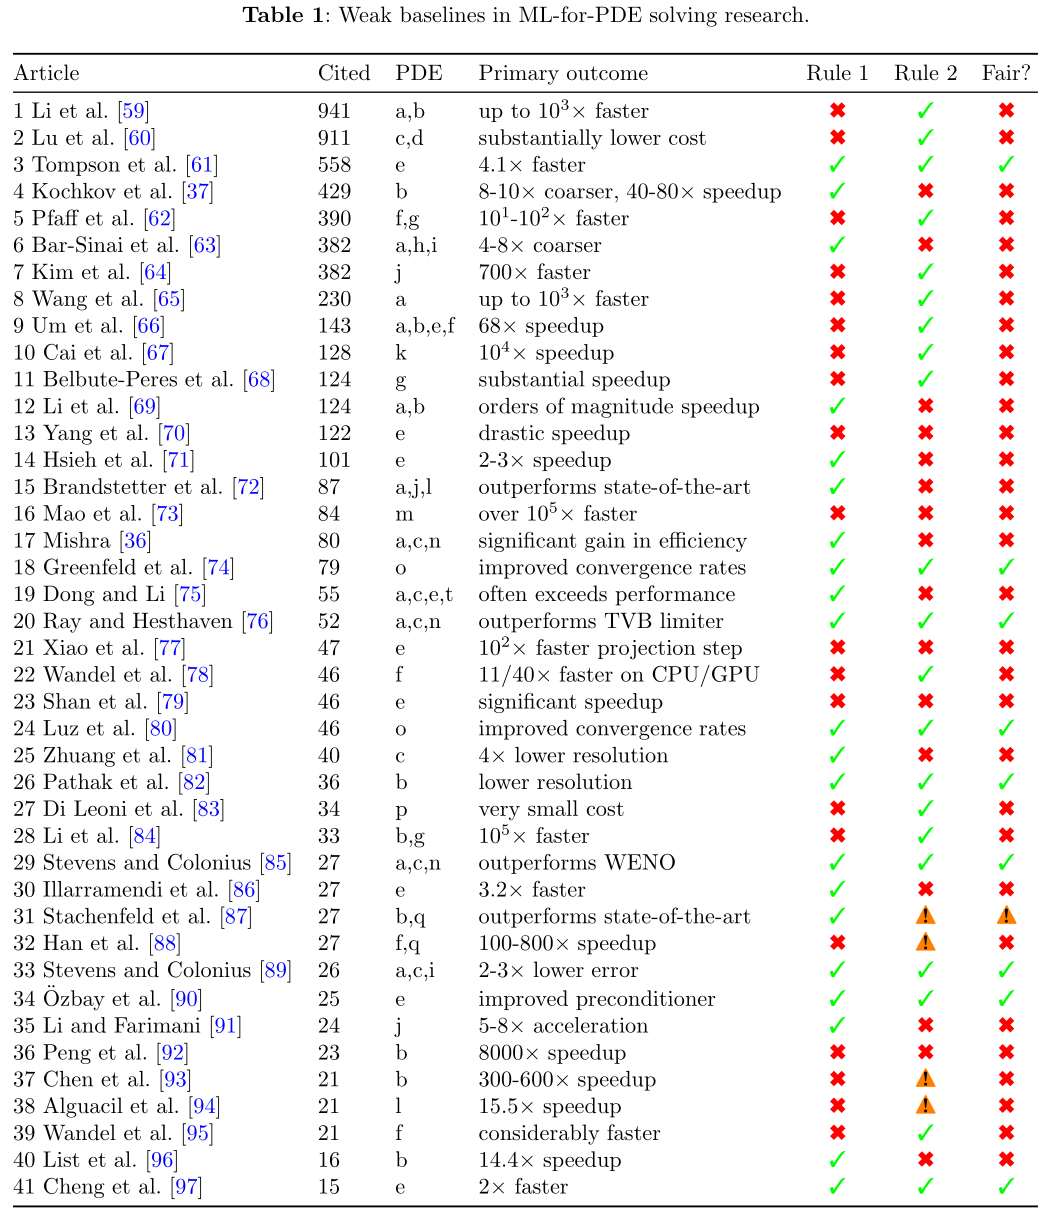

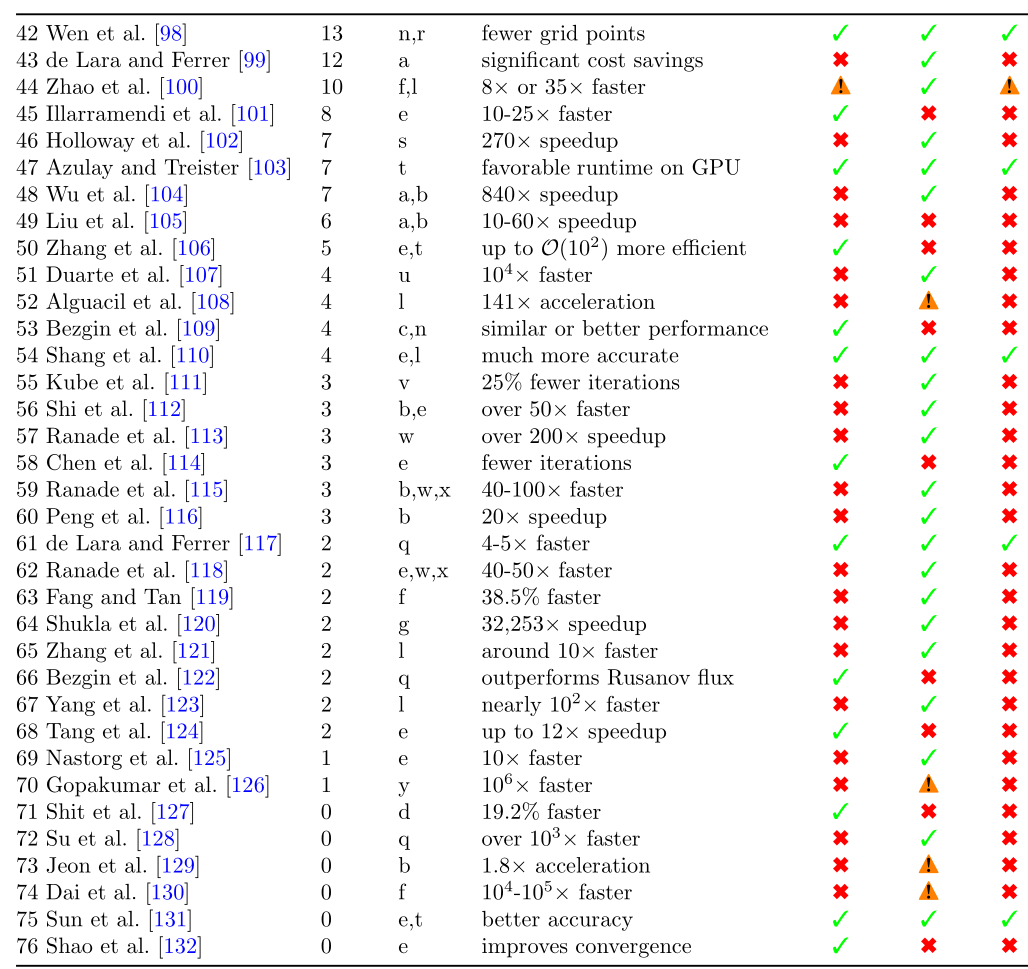

<img src="figures/mechanism-data.png" width="60%" />

# Constitutive relation inference

<img src="figures/crikit-workflow.svg" width="90%" />

# Outlook

* Datacenter energy consumption > 5% of all electricity use in the US
* Comparable energy/emissions to global aviation
* Cost is correlated to emissions
* Beware of accounting tricks to deflate reported emissions
* Focus on epistemic soundness
* Choose good data structures and libraries, Pareto-optimal methods

<img src="figures/ratel/die-press-half-zach.png" />